# Movie Recommendation System
**Dataset** : MovieLens ml-latest-small (9,742 movies, 100,836 ratings)  
**Method**  : Content-Based Filtering using Cosine Similarity  
**Input**   : User selects favourite genres  
**Output**  : Top 10 recommended movies

## Step 1: Load Dataset

In [2]:
import pandas as pd
import numpy as np

movies  = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

print(f"Movies  : {movies.shape[0]:,} rows")
print(f"Ratings : {ratings.shape[0]:,} rows")
print()
movies.head()

Movies  : 9,742 rows
Ratings : 100,836 rows



,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Step 2: Preprocess — Genre Encoding + Average Rating

In [3]:
# One-hot encode genres
genre_dummies = movies["genres"].str.get_dummies(sep="|")
movies_encoded = pd.concat([movies[["movieId", "title"]], genre_dummies], axis=1)

# Compute average rating per movie
avg_ratings = (ratings.groupby("movieId")["rating"]
               .agg(avg_rating="mean", num_ratings="count")
               .reset_index())

# Merge
movies_encoded = movies_encoded.merge(avg_ratings, on="movieId", how="left")
movies_encoded["avg_rating"] = movies_encoded["avg_rating"].fillna(0)

# Keep only movies with at least 10 ratings
movies_filtered = movies_encoded[movies_encoded["num_ratings"] >= 10].reset_index(drop=True)

print(f"Movies after filtering (>=10 ratings): {len(movies_filtered):,}")
print(f"Genres available: {list(genre_dummies.columns)}")
movies_filtered.head()

Movies after filtering (>=10 ratings): 2,269
Genres available: ['(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


,movieId,title,(no genres listed),Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,avg_rating,num_ratings
0,1,Toy Story (1995),0,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,3.920930,215.0
1,2,Jumanji (1995),0,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,3.431818,110.0
2,3,Grumpier Old Men (1995),0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,0,0,3.259615,52.0
3,5,Father of the Bride Part II (1995),0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,3.071429,49.0
4,6,Heat (1995),0,1,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,3.946078,102.0


## Step 3: Get User Preferences

In [4]:
genre_cols = [c for c in movies_filtered.columns
              if c not in ["movieId", "title", "avg_rating", "num_ratings", "(no genres listed)"]]

print("Available genres:")
for i, g in enumerate(genre_cols, 1):
    print(f"  {i:2}. {g}")

print()
print("Enter genre numbers you like (comma-separated), e.g.: 1,4,7")
selected = input("Your choices: ")

chosen = []
for s in selected.split(","):
    s = s.strip()
    if s.isdigit():
        idx = int(s) - 1
        if 0 <= idx < len(genre_cols):
            chosen.append(genre_cols[idx])

print(f"\nSelected genres: {chosen}")

Available genres:
   1. Action
   2. Adventure
   3. Animation
   4. Children
   5. Comedy
   6. Crime
   7. Documentary
   8. Drama
   9. Fantasy
  10. Film-Noir
  11. Horror
  12. IMAX
  13. Musical
  14. Mystery
  15. Romance
  16. Sci-Fi
  17. Thriller
  18. War
  19. Western

Enter genre numbers you like (comma-separated), e.g.: 1,4,7
Your choices: 1

Selected genres: ['Action']


## Step 4: Compute Cosine Similarity

In [5]:
from sklearn.metrics.pairwise import cosine_similarity

# Build user vector (genres + normalised rating weight)
user_vector = np.zeros(len(genre_cols) + 1)
for genre in chosen:
    if genre in genre_cols:
        user_vector[genre_cols.index(genre)] = 1
user_vector[-1] = 1  # prefer high-rated movies

# Build movie matrix
feature_cols = genre_cols + ["avg_rating"]
movies_filtered["avg_rating_norm"] = movies_filtered["avg_rating"] / 5
movie_matrix = movies_filtered[genre_cols + ["avg_rating_norm"]].values

# Compute similarity
similarities = cosine_similarity([user_vector], movie_matrix)[0]
movies_filtered = movies_filtered.copy()
movies_filtered["similarity"] = similarities

print("Similarity computed for all movies.")

Similarity computed for all movies.


## Step 5: Top 10 Recommendations

In [6]:
top10 = (movies_filtered
         .sort_values("similarity", ascending=False)
         .head(10)[["title", "avg_rating", "num_ratings", "similarity"]]
         .reset_index(drop=True))

top10.index += 1
top10["similarity"] = (top10["similarity"] * 100).round(1).astype(str) + "%"
top10["avg_rating"] = top10["avg_rating"].round(2)

print("🎬 Top 10 Movie Recommendations:\n")
print(top10.to_string())

🎬 Top 10 Movie Recommendations:

                                                                             title  avg_rating  num_ratings similarity
1                                                              Sudden Death (1995)        3.12         16.0      97.4%
2                                             Under Siege 2: Dark Territory (1995)        2.72         30.0      95.9%
3                                                                     Logan (2017)        4.28         25.0      79.4%
4                                                                   Yojimbo (1961)        4.23         13.0      79.2%
5   Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)        4.21        200.0      79.1%
6                               Legend of Drunken Master, The (Jui kuen II) (1994)        4.12         16.0      78.8%
7                                                 Drunken Master (Jui kuen) (1978)        4.05         10.0      78.5%
8              

## Step 6: Visualize

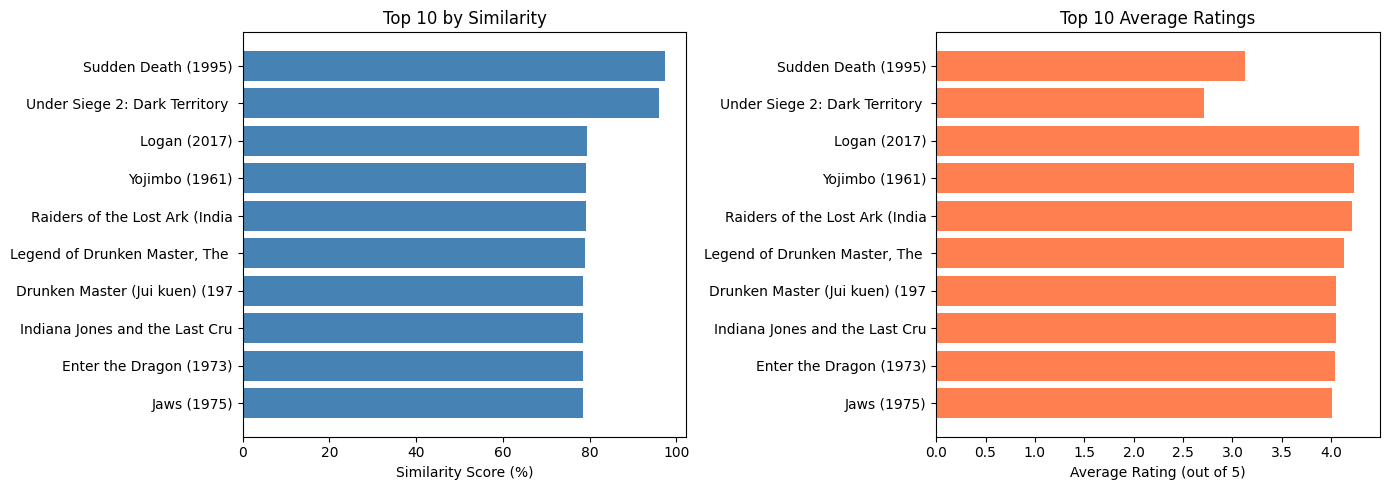

In [7]:
import matplotlib.pyplot as plt

top10_viz = (movies_filtered
             .sort_values("similarity", ascending=False)
             .head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Similarity bar chart
axes[0].barh(top10_viz["title"].str[:30][::-1],
             top10_viz["similarity"][::-1] * 100,
             color="steelblue")
axes[0].set_xlabel("Similarity Score (%)")
axes[0].set_title("Top 10 by Similarity")

# Rating bar chart
axes[1].barh(top10_viz["title"].str[:30][::-1],
             top10_viz["avg_rating"][::-1],
             color="coral")
axes[1].set_xlabel("Average Rating (out of 5)")
axes[1].set_title("Top 10 Average Ratings")

plt.tight_layout()
plt.show()